In [1]:
from google.colab import files

In [2]:
uploaded = files.upload()

Saving 1730285881-Airbnb_Open_Data.xlsx to 1730285881-Airbnb_Open_Data.xlsx


In [3]:
!pip install pandas matplotlib seaborn openpyxl


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_excel("1730285881-Airbnb_Open_Data.xlsx")
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())


Dataset Shape: (102599, 26)
Columns: ['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


In [8]:
df.drop_duplicates(inplace=True)
df.dropna(thresh=len(df.columns)//2, inplace=True)

for col in df.select_dtypes(include=["float64", "int64"]).columns:
   df[col] = df[col].fillna(df[col].median())


for col in df.select_dtypes(include=["object"]).columns:
   df[col] = df[col].fillna("Unknown")


print("\nCleaned Dataset Shape:", df.shape)



Cleaned Dataset Shape: (102058, 26)


In [10]:
#Explore Column Names Again
print("\nRoom Type Distribution:")
print(df["room type"].value_counts())

print("\nNeighbourhood Distribution:")
print(df["neighbourhood group"].value_counts().head(10))

print("\nAverage Price per Room Type:")
print(df.groupby("room type")["price"].mean())


In [11]:
#Basic Summary Statistics
print(df.columns.tolist())


['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


In [12]:
print("\nDataset Summary:")
print(df.describe(include="all"))



Dataset Summary:
                  id     NAME       host id host_identity_verified host name  \
count   1.020580e+05   102058  1.020580e+05                 102058    102058   
unique           NaN    61281           NaN                      3     13190   
top              NaN  Unknown           NaN            unconfirmed   Michael   
freq             NaN      270           NaN                  50944       878   
mean    2.918438e+07      NaN  4.926738e+10                    NaN       NaN   
min     1.001254e+06      NaN  1.236005e+08                    NaN       NaN   
25%     1.509286e+07      NaN  2.459924e+10                    NaN       NaN   
50%     2.918438e+07      NaN  4.912865e+10                    NaN       NaN   
75%     4.327590e+07      NaN  7.400619e+10                    NaN       NaN   
max     5.736742e+07      NaN  9.876313e+10                    NaN       NaN   
std     1.627173e+07      NaN  2.853742e+10                    NaN       NaN   

       neighbourhood 

/tmp/ipython-input-3336525934.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="room type", data=df, palette="viridis")


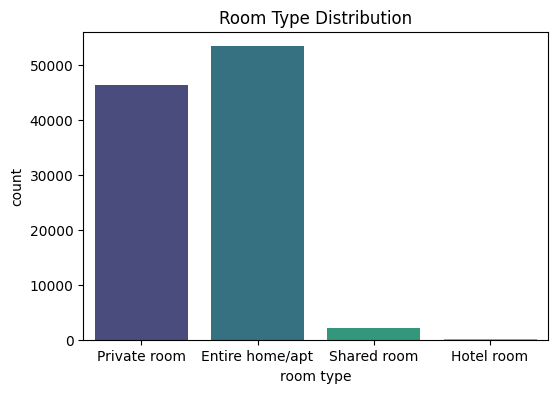

In [13]:
#Visualizations (EDA)-Room type distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="room type", data=df, palette="viridis")
plt.title("Room Type Distribution")
plt.show()


/tmp/ipython-input-1078050758.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="room type", y="price", data=df, palette="magma", estimator="mean")


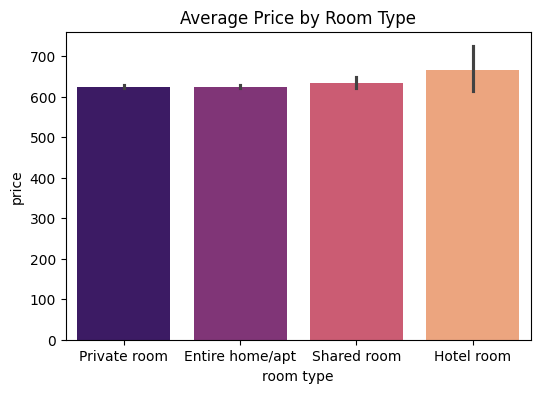

In [14]:
#Average price by room type
plt.figure(figsize=(6,4))
sns.barplot(x="room type", y="price", data=df, palette="magma", estimator="mean")
plt.title("Average Price by Room Type")
plt.show()


/tmp/ipython-input-1144716094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighbourhoods.index, y=top_neighbourhoods.values, palette="coolwarm")


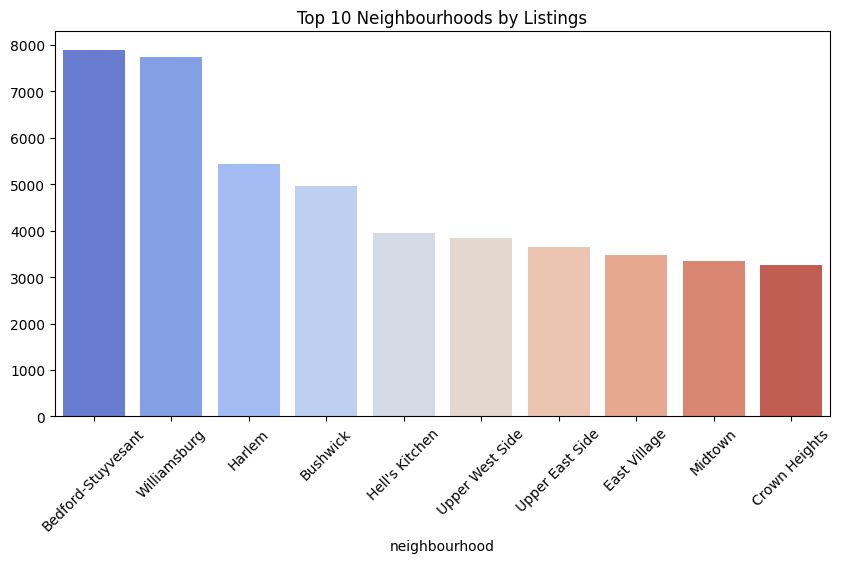

In [15]:
#Top 10 neighbourhoods by listings
plt.figure(figsize=(10,5))
top_neighbourhoods = df["neighbourhood"].value_counts().head(10)
sns.barplot(x=top_neighbourhoods.index, y=top_neighbourhoods.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Top 10 Neighbourhoods by Listings")
plt.show()


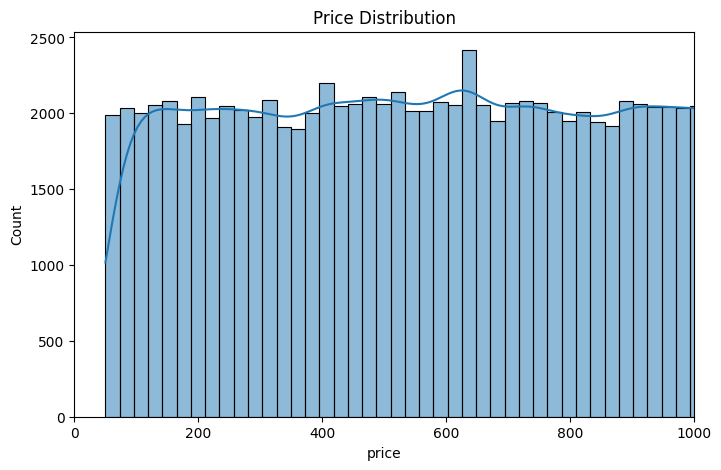

In [16]:
#Price distribution (limit outliers)
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.xlim(0, 1000)
plt.title("Price Distribution")
plt.show()


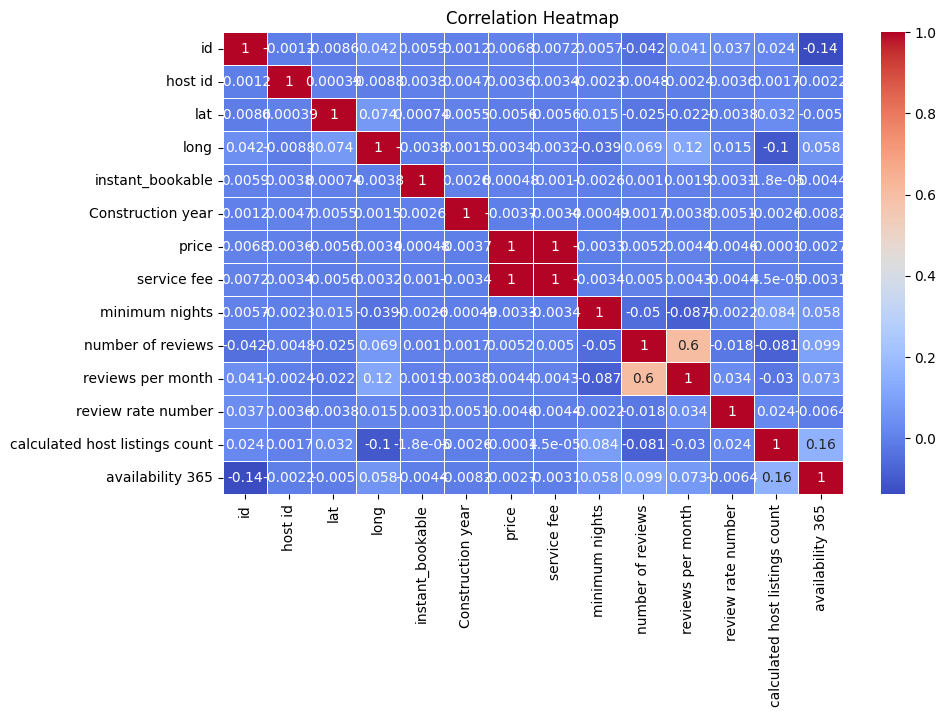

In [17]:
#Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()